# Question 1: Depths, Widths and Learning Rates (20 Points)

In [16]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

# Fix Seeds for Reproducibility
# NOTE: do not modify the seed value. 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# torch.set_default_dtype(torch.double)
torch.set_default_dtype(torch.float)

PyTorch offers domain-specific libraries such as TorchText, TorchVision, and TorchAudio, all of which include datasets. For this tutorial, we will be using a TorchVision dataset.

The torchvision.datasets module contains Dataset objects for many real-world vision data like CIFAR, COCO. In this tutorial, we use the KMNIST dataset. Every TorchVision Dataset includes two arguments: transform and target_transform to modify the samples and labels respectively.

In [17]:
# Download training data from open datasets.
training_data = datasets.KMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.KMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

## (a) Dataset Overview (1 Points)

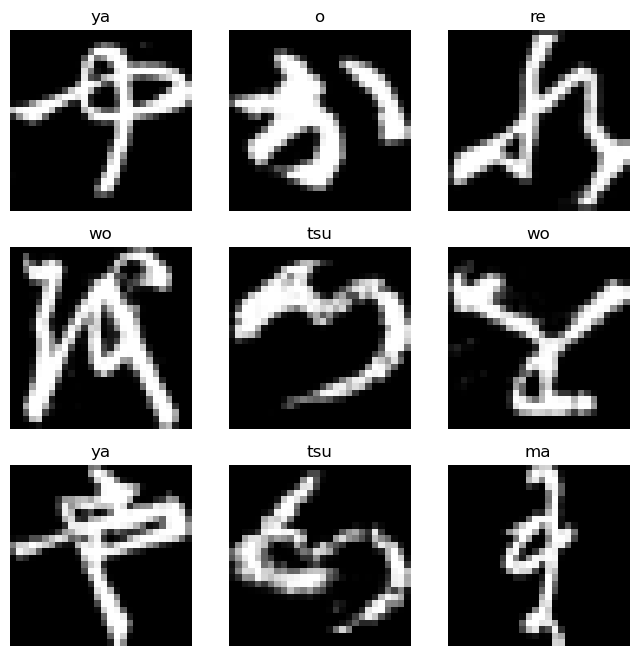

In [18]:
classes = {
    0: "o",
    1: "ki",
    2: "su",
    3: "tsu",
    4: "na",
    5: "ha",
    6: "ma",
    7: "ya",
    8: "re",
    9: "wo",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(classes[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

We pass the Dataset as an argument to DataLoader. This wraps an iterable over our dataset, and supports automatic batching, sampling, shuffling and multiprocess data loading. Here we define a batch size of 64, i.e. each element in the dataloader iterable will return a batch of 64 features and labels.

In [19]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print("Shape of X [N, C, H, W]: ", X.shape)
    print("Shape of y: ", y.shape, y.dtype)
    break

Shape of X [N, C, H, W]:  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


## (b) Define the Neural Network (5 Points)
In this task you are asked to define a shallow network with two layers.

In [20]:
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

# Define model
##############
# TODO (b) Define a neural network that takes `width` and `depth` (number of hidden layers) as input. 
# 1. Use flatten to move your (28,28) image to a vector.
# 2. Between your layers use a ReLU activation function.
# 3. The network should handle variable depth.
# 4. Do not use an activation function after your final layer (logits).
##############
class NeuralNetwork(nn.Module):
    def __init__(self, width, hidden_layers):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        # Initialize layers here based on width and depth
        layers = [self.flatten]
        input_size = 28 * 28
        
        # Add hidden layers with ReLU activation
        for _ in range(hidden_layers):
            layers.append(nn.Linear(input_size, width))
            layers.append(nn.ReLU())
            input_size = width
        
        # Add output layer (no activation)
        layers.append(nn.Linear(input_size, 10))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # Implement forward pass
        return self.model(x)

Using mps device


## (c) Define the training & testing loop (4 Points)
In a single training loop, the model makes predictions on the training dataset (fed to it in batches), and backpropagates the prediction error to adjust the model’s parameters.

In [21]:
def train(dataloader, model, loss_fn, optimizer, records, global_step):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # TODO (c) Implement the training loop. 
        # Compute the prediction error 'loss' followed by a backpropagation step.
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        global_step += 1

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

            # Update records
            records['step'].append(global_step)
            records['train_loss'].append(loss)
            records['train_acc'].append((pred.argmax(1) == y).type(torch.float).mean().item())

    return global_step

We also check the model’s performance against the test dataset to ensure it is learning.

In [22]:
def test(dataloader, model, loss_fn, records, global_step):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    # Update records
    records['eval_step'].append(global_step)
    records['test_loss'].append(test_loss)
    records['test_acc'].append(correct)

    return test_loss, 100 * correct

In [23]:
def plot_training_records(records, title):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Loss', color='tab:red')
    # Draw Loss curves (Train & Test)
    l1, = ax1.plot(records['step'], records['train_loss'], label='Train Loss', color='tab:red', alpha=0.6, linewidth=2)
    l2, = ax1.plot(records['eval_step'], records['test_loss'], label='Test Loss', color='darkred', marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Create a second y-axis sharing the same x-axis
    ax2 = ax1.twinx()  
    ax2.set_ylabel('Accuracy', color='tab:blue')
    # Draw Accuracy curves (Train & Test)
    l3, = ax2.plot(records['step'], records['train_acc'], label='Train Acc', color='tab:blue', alpha=0.5, linewidth=2)
    l4, = ax2.plot(records['eval_step'], records['test_acc'], label='Test Acc', color='darkblue', marker='o', linewidth=2)
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, 1.0) # Accuracy range fixed at 0-1

    # Merge legends
    lines = [l1, l2, l3, l4]
    labels = [l.get_label() for l in lines]
    plt.legend(lines, labels, loc='center right')
    
    plt.title(f'Training & Evaluation Metrics ({title})')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{title}.png")
    plt.show()

Before we can train the network, we have to create the network, choose a criterion (loss function) and create an optimizer.

In [24]:
# TODO:
# Define a neural network that has a width of 512 and a depth of 1.
width = 512
depth = 1

model = NeuralNetwork(width=width, hidden_layers=depth).to(device)
print(model)

# TODO:
# Use SGD optimizer from PyTorch with learning rate 1e-2
learning_rate = 1e-2
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# TODO:
# Use CrossEntropyLoss from PyTorch as criterion
loss_fn = nn.CrossEntropyLoss()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


Now we can train the network.

Epoch 1
-------------------------------
loss: 2.301709  [    0/60000]
loss: 2.089467  [ 6400/60000]
loss: 1.805368  [12800/60000]
loss: 1.641330  [19200/60000]
loss: 1.177485  [25600/60000]
loss: 1.194581  [32000/60000]
loss: 1.189431  [38400/60000]
loss: 0.975590  [44800/60000]
loss: 0.835351  [51200/60000]
loss: 0.994195  [57600/60000]
Test Error: 
 Accuracy: 60.1%, Avg loss: 1.296812 

Epoch 2
-------------------------------
loss: 0.935235  [    0/60000]
loss: 0.879625  [ 6400/60000]
loss: 0.884281  [12800/60000]
loss: 0.839027  [19200/60000]
loss: 0.532669  [25600/60000]
loss: 0.717941  [32000/60000]
loss: 0.755707  [38400/60000]
loss: 0.702990  [44800/60000]
loss: 0.522450  [51200/60000]
loss: 0.766451  [57600/60000]
Test Error: 
 Accuracy: 66.4%, Avg loss: 1.074958 

Epoch 3
-------------------------------
loss: 0.713126  [    0/60000]
loss: 0.736848  [ 6400/60000]
loss: 0.737809  [12800/60000]
loss: 0.678807  [19200/60000]
loss: 0.421486  [25600/60000]
loss: 0.599144  [32000/600

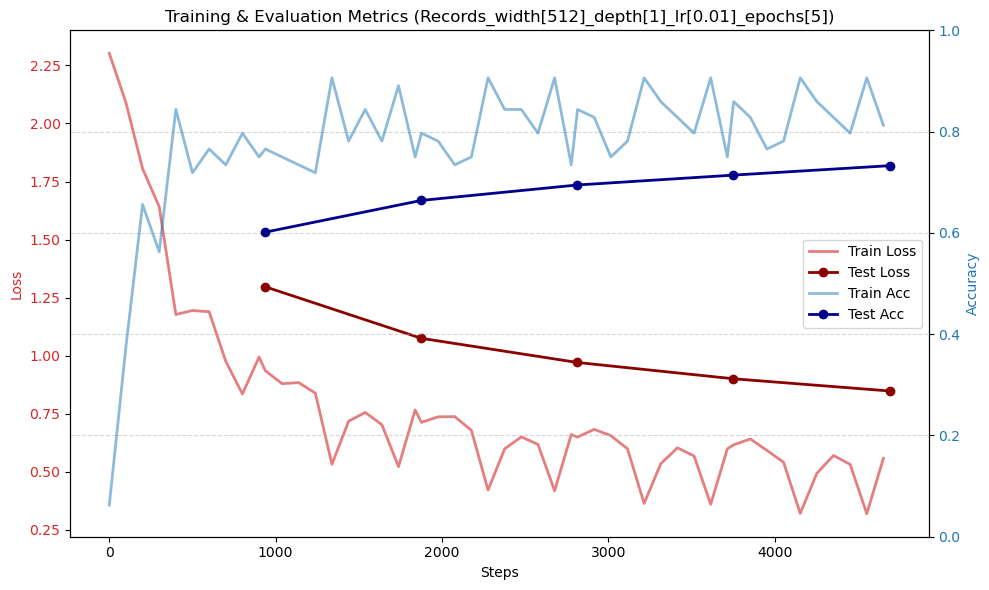

Done!


In [25]:
epochs = 5
# Initialize records
records = {
    'step': [],
    'train_loss': [],
    'train_acc': [],
    'eval_step': [],
    'test_loss': [],
    'test_acc': []
}
global_step = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    global_step = train(train_dataloader, model, loss_fn, optimizer, records, global_step)
    _, _ = test(test_dataloader, model, loss_fn, records, global_step)

# Plot training and test records
plot_training_records(records, f"Records_width[{width}]_depth[{depth}]_lr[{learning_rate}]_epochs[{epochs}]")
print("Done!")

## (d) Architecture Comparison (2 Points)
In this task, you are asked to perform a grid search over different combinations of widths and depths of the network. For each configuration, you are required to train the model for 5 epochs with the learning rate of 0.01. Record the test accuracy and average loss for each configuration.

In [26]:
def plot_metric(results, metric_key, x_key, group_key=None, title=None, ylabel=None, log_x=False):
    plt.figure(figsize=(10, 6))
    
    if group_key:
        unique_groups = sorted(list(set(r[group_key] for r in results)))
    else:
        unique_groups = [None]
    
    cmap = plt.get_cmap('tab10')
    
    for i, group in enumerate(unique_groups):
        if group is not None:
            subset = [r for r in results if r[group_key] == group]
            label = f'{group_key}: {group}'
        else:
            subset = results
            label = 'All Data'
            
        subset.sort(key=lambda r: r[x_key])
        
        xs = [r[x_key] for r in subset]
        ys = [r[metric_key] for r in subset]
        
        color = cmap(i % 10)
        plt.scatter(xs, ys, label=label, color=color, s=100, alpha=0.7, edgecolors='k')
        plt.plot(xs, ys, color=color, linestyle='--', alpha=0.3)

    plt.title(title if title else f'{metric_key} over {x_key}')
    plt.xlabel(x_key)
    plt.ylabel(ylabel if ylabel else metric_key)
    
    plt.grid(True, which="both", ls="-", alpha=0.2)
    if group_key: 
        plt.legend()
    plt.xscale('log' if log_x else 'linear')
    plt.tight_layout()
    plt.savefig(f"{title}.png")
    plt.show()

loss: 2.293699  [    0/60000]
loss: 2.164285  [ 6400/60000]
loss: 1.935742  [12800/60000]
loss: 1.707057  [19200/60000]
loss: 1.324675  [25600/60000]
loss: 1.274271  [32000/60000]
loss: 1.282326  [38400/60000]
loss: 1.002121  [44800/60000]
loss: 0.869737  [51200/60000]
loss: 1.021145  [57600/60000]
Test Error: 
 Accuracy: 59.9%, Avg loss: 1.336937 

loss: 0.961967  [    0/60000]
loss: 0.913005  [ 6400/60000]
loss: 0.943906  [12800/60000]
loss: 0.829199  [19200/60000]
loss: 0.555996  [25600/60000]
loss: 0.751880  [32000/60000]
loss: 0.802502  [38400/60000]
loss: 0.723041  [44800/60000]
loss: 0.544991  [51200/60000]
loss: 0.771311  [57600/60000]
Test Error: 
 Accuracy: 66.0%, Avg loss: 1.102193 

loss: 0.733523  [    0/60000]
loss: 0.747939  [ 6400/60000]
loss: 0.782263  [12800/60000]
loss: 0.678872  [19200/60000]
loss: 0.432175  [25600/60000]
loss: 0.636568  [32000/60000]
loss: 0.688610  [38400/60000]
loss: 0.647593  [44800/60000]
loss: 0.450100  [51200/60000]
loss: 0.671659  [57600/600

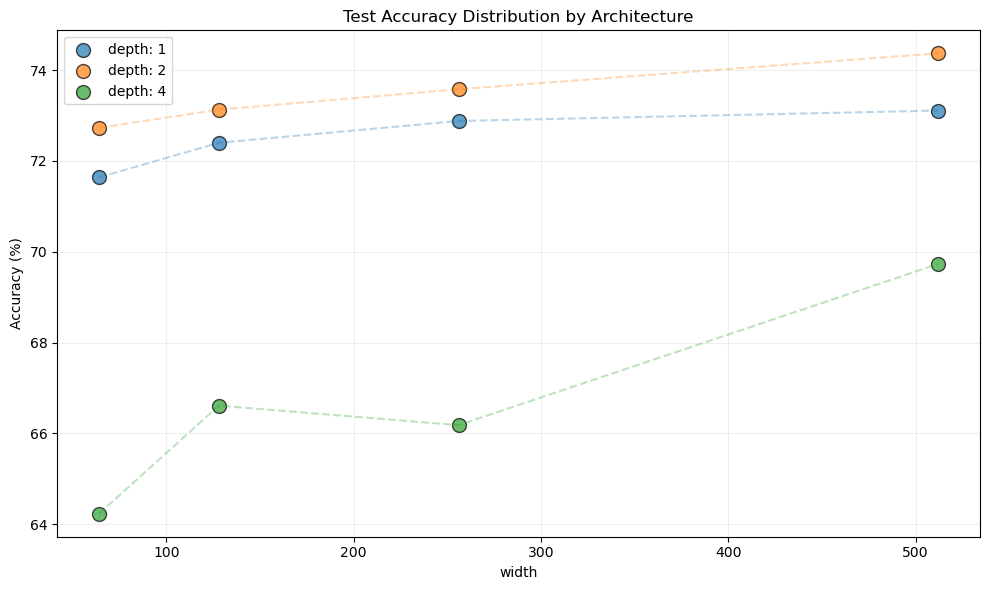

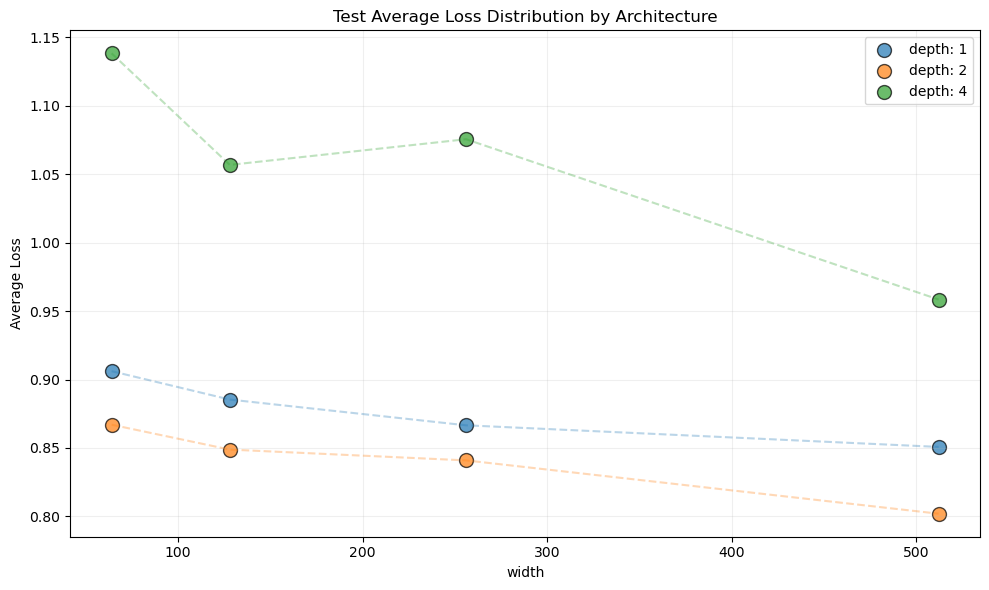

In [27]:
# TODO:
# Write a script (recommended) or rerun the aforementioned code cells to loop through the specified configurations.

# Please analyze the following configurations:
# Depth: 1, 2, 4
# Width: 64, 128, 256, 512
# Organize results as a list of dictionaries with the following keys:
# experiment_results = [
#     {'depth': 1, 'width': 64, 'accuracy': , 'loss': }, # depth 1, width 64
#     {'depth': 1, 'width': 128, 'accuracy': , 'loss': }, # depth 1, width 128
#     ...
#     ]
experiment_results = []
for depth in [1, 2, 4]:
    for width in [64, 128, 256, 512]:
        # Initialize model, optimizer, and loss function
        model = NeuralNetwork(width=width, hidden_layers=depth).to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
        loss_fn = nn.CrossEntropyLoss()
        
        # Reset records and global step
        records = {
            'step': [],
            'train_loss': [],
            'train_acc': [],
            'eval_step': [],
            'test_loss': [],
            'test_acc': []
        }
        global_step = 0
        
        # Train and evaluate the model
        epochs = 5
        for t in range(epochs):
            global_step = train(train_dataloader, model, loss_fn, optimizer, records, global_step)
            _, _ = test(test_dataloader, model, loss_fn, records, global_step)
        
        # Store final accuracy and loss
        experiment_results.append({
            'depth': depth,
            'width': width,
            'accuracy': records['test_acc'][-1] * 100,  # Convert to percentage
            'loss': records['test_loss'][-1]
        })

# Plot Accuracy distribution
plot_metric(experiment_results, 'accuracy', 'width', 'depth',
            'Test Accuracy Distribution by Architecture', 'Accuracy (%)')

# Plot Avg Loss distribution
plot_metric(experiment_results, 'loss', 'width', 'depth',
            'Test Average Loss Distribution by Architecture', 'Average Loss')

## (e) Learning Rate Comparison (2 Points)
In this task, you are asked to perform a grid search over different learning rates: [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]. For each learning rate, you are required to train the model for 5 epochs with the width of 512 and depth of 1. Record the test accuracy and average loss for each learning rate.

loss: 2.326915  [    0/60000]
loss: 0.755301  [ 6400/60000]
loss: 0.386075  [12800/60000]
loss: 0.420590  [19200/60000]
loss: 0.174696  [25600/60000]
loss: 0.389646  [32000/60000]
loss: 0.308095  [38400/60000]
loss: 0.282061  [44800/60000]
loss: 0.157878  [51200/60000]
loss: 0.171202  [57600/60000]
Test Error: 
 Accuracy: 86.5%, Avg loss: 0.443239 

loss: 0.335990  [    0/60000]
loss: 0.237584  [ 6400/60000]
loss: 0.157654  [12800/60000]
loss: 0.106196  [19200/60000]
loss: 0.114283  [25600/60000]
loss: 0.179202  [32000/60000]
loss: 0.100212  [38400/60000]
loss: 0.306426  [44800/60000]
loss: 0.043278  [51200/60000]
loss: 0.062375  [57600/60000]
Test Error: 
 Accuracy: 89.1%, Avg loss: 0.399030 

loss: 0.162532  [    0/60000]
loss: 0.132450  [ 6400/60000]
loss: 0.042810  [12800/60000]
loss: 0.035414  [19200/60000]
loss: 0.116015  [25600/60000]
loss: 0.073577  [32000/60000]
loss: 0.042167  [38400/60000]
loss: 0.207685  [44800/60000]
loss: 0.067384  [51200/60000]
loss: 0.060834  [57600/600

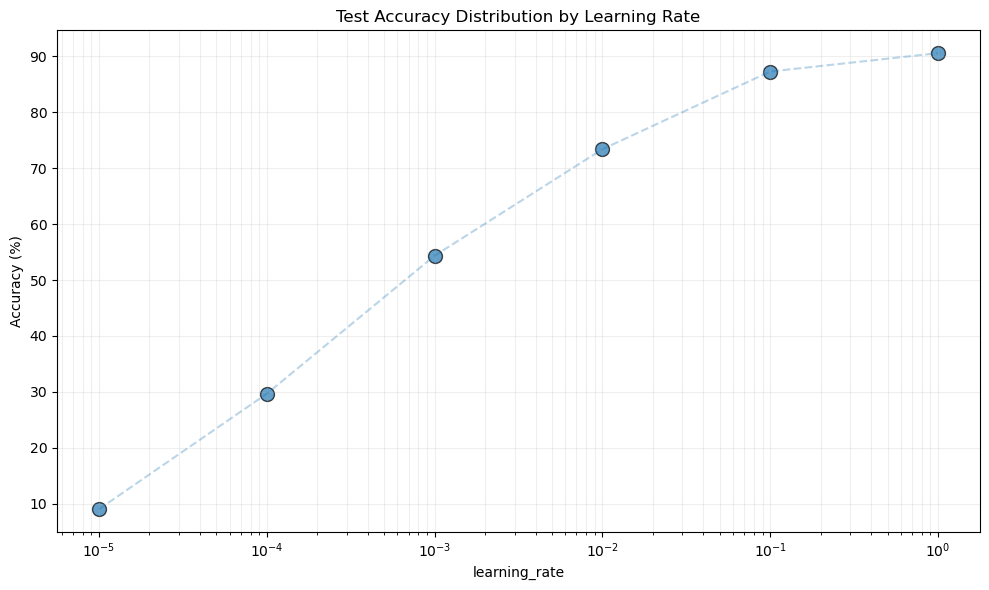

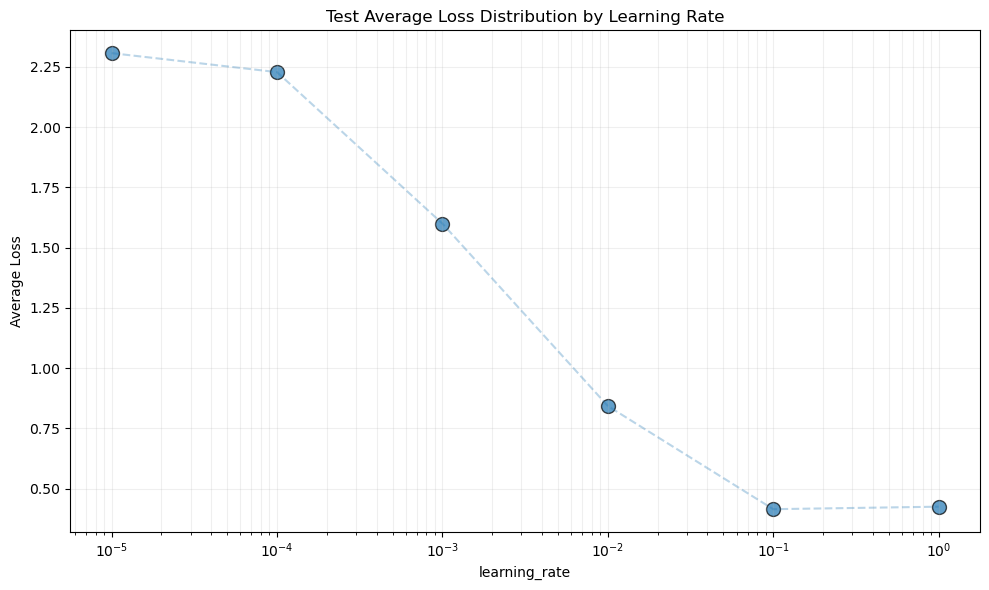

In [28]:
# TODO:
# Write a script (recommended) or rerun the aforementioned code cells to loop through the specified configurations.

# Please analyze the following configurations:
# Learning Rates: 1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5
# Organize results as a list of dictionaries with the following keys:
# experiment_results = [
#     {'learning_rate': 1, 'accuracy': , 'loss': }, # learning rate 1
#     {'learning_rate': 1e-1, 'accuracy': , 'loss': }, # learning rate 1e-1
#     ...
#     ]
experiment_results = []
for lr in [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    # Initialize model, optimizer, and loss function
    model = NeuralNetwork(width=512, hidden_layers=1).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    # Reset records and global step
    records = {
        'step': [],
        'train_loss': [],
        'train_acc': [],
        'eval_step': [],
        'test_loss': [],
        'test_acc': []
    }
    global_step = 0
    
    # Train and evaluate the model
    epochs = 5
    for t in range(epochs):
        global_step = train(train_dataloader, model, loss_fn, optimizer, records, global_step)
        _, _ = test(test_dataloader, model, loss_fn, records, global_step)
    
    # Store final accuracy and loss
    experiment_results.append({
        'learning_rate': lr,
        'accuracy': records['test_acc'][-1] * 100,  # Convert to percentage
        'loss': records['test_loss'][-1]
    })

# Plot Accuracy distribution
plot_metric(experiment_results, 'accuracy', 'learning_rate', None,
            'Test Accuracy Distribution by Learning Rate', 'Accuracy (%)', log_x=True)

# Plot Avg Loss distribution
plot_metric(experiment_results, 'loss', 'learning_rate', None,
            'Test Average Loss Distribution by Learning Rate', 'Average Loss', log_x=True)

## (f) Epoch Comparison (2 Points)
In this task, you are asked to perform a grid search over different epoch counts: [1, 2, ..., 20]. For each epoch count, you are required to train the model with the width of 512 and depth of 1, using a learning rate of 0.01. Record the test accuracy and average loss for each epoch count.

loss: 2.316766  [    0/60000]
loss: 2.086474  [ 6400/60000]
loss: 1.799640  [12800/60000]
loss: 1.629646  [19200/60000]
loss: 1.171105  [25600/60000]
loss: 1.180841  [32000/60000]
loss: 1.207667  [38400/60000]
loss: 0.973788  [44800/60000]
loss: 0.826743  [51200/60000]
loss: 0.980284  [57600/60000]
Test Error: 
 Accuracy: 60.4%, Avg loss: 1.300239 

loss: 2.315847  [    0/60000]
loss: 2.095537  [ 6400/60000]
loss: 1.804821  [12800/60000]
loss: 1.638378  [19200/60000]
loss: 1.202034  [25600/60000]
loss: 1.221803  [32000/60000]
loss: 1.201516  [38400/60000]
loss: 0.973543  [44800/60000]
loss: 0.823447  [51200/60000]
loss: 1.005819  [57600/60000]
Test Error: 
 Accuracy: 60.1%, Avg loss: 1.299897 

loss: 0.947873  [    0/60000]
loss: 0.871119  [ 6400/60000]
loss: 0.876087  [12800/60000]
loss: 0.814378  [19200/60000]
loss: 0.537191  [25600/60000]
loss: 0.730109  [32000/60000]
loss: 0.759771  [38400/60000]
loss: 0.710921  [44800/60000]
loss: 0.516488  [51200/60000]
loss: 0.761112  [57600/600

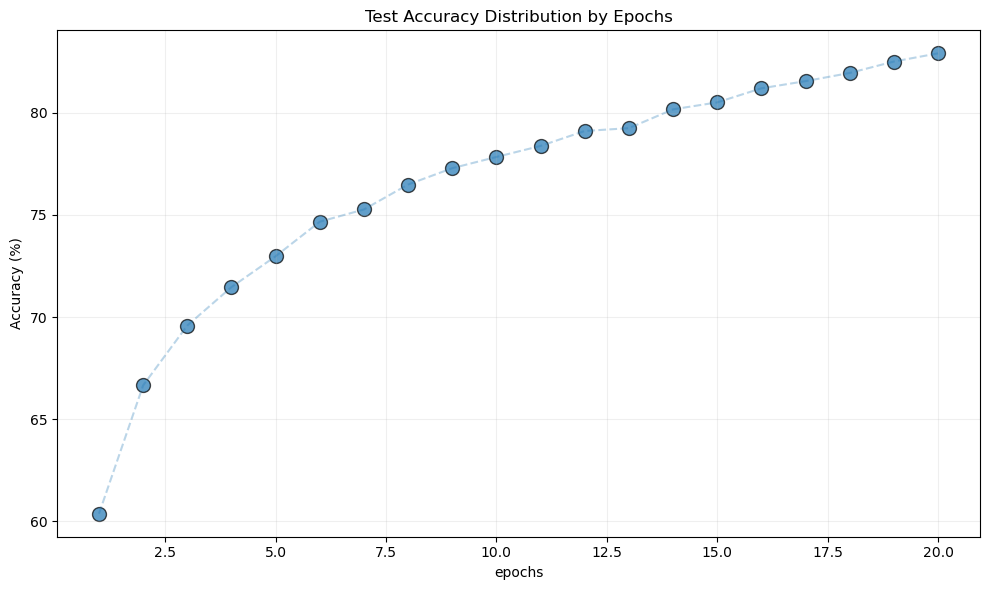

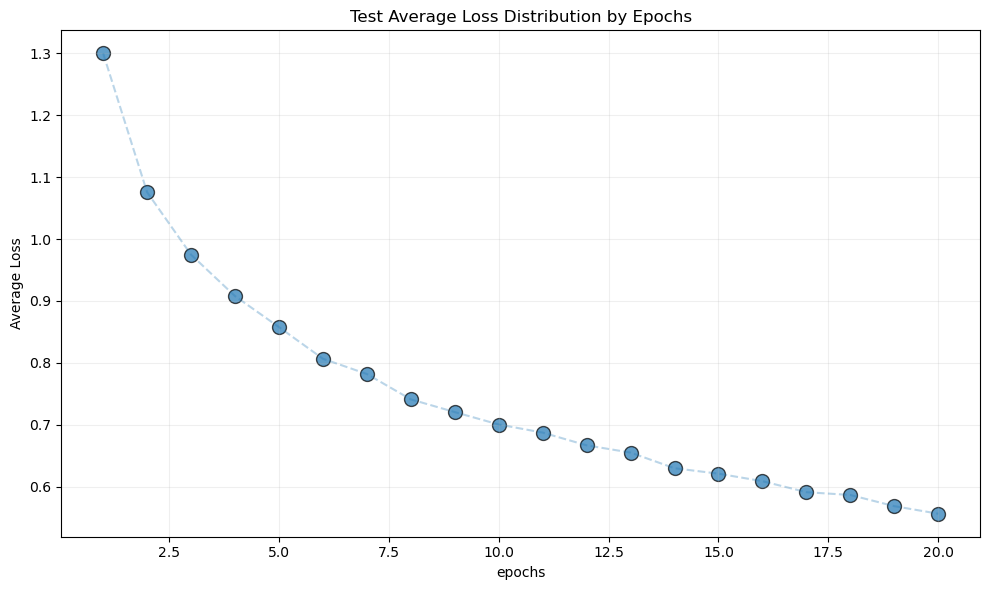

In [29]:
# TODO:
# Write a script (recommended) or rerun the aforementioned code cells to loop through the specified configurations.
# Please analyze the following configurations:
# Epochs: 1, 2, 3, ..., 20
# Organize results as a list of dictionaries with the following keys:
# experiment_results = [
#     {'epochs': 1, 'accuracy': , 'loss': }, # epochs 1
#     {'epochs': 2, 'accuracy': , 'loss': }, # epochs 2
#     ...
#     ]
experiment_results = []
for epochs in np.arange(1, 21):
    # Initialize model, optimizer, and loss function
    model = NeuralNetwork(width=512, hidden_layers=1).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
    loss_fn = nn.CrossEntropyLoss()
    
    # Reset records and global step
    records = {
        'step': [],
        'train_loss': [],
        'train_acc': [],
        'eval_step': [],
        'test_loss': [],
        'test_acc': []
    }
    global_step = 0
    
    # Train and evaluate the model
    # epochs = 5
    for t in range(epochs):
        global_step = train(train_dataloader, model, loss_fn, optimizer, records, global_step)
        _, _ = test(test_dataloader, model, loss_fn, records, global_step)
    
    # Store final accuracy and loss
    experiment_results.append({
        'epochs': epochs,
        'accuracy': records['test_acc'][-1] * 100,  # Convert to percentage
        'loss': records['test_loss'][-1]
    })


# Plot Accuracy distribution
plot_metric(experiment_results, 'accuracy', 'epochs', None,
            'Test Accuracy Distribution by Epochs', 'Accuracy (%)')

# Plot Avg Loss distribution
plot_metric(experiment_results, 'loss', 'epochs', None,
            'Test Average Loss Distribution by Epochs', 'Average Loss')

## (g) Save and Load Model (2 Points)
After training, you can save the model to disk. Later, you can load the model from disk and use it to make predictions.

In [30]:
# TODO: g) Save your model as a .pth file
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [33]:
# TODO g) Load your previously saved model.
model = NeuralNetwork(width=512, hidden_layers=1).to(device)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

## (h) Predictions (2 Points)
Finally, you can use the trained model to make predictions on new data.

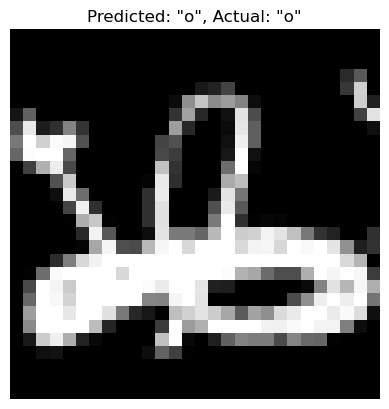

In [34]:
classes = [
    "o", "ki", "su", "tsu", "na", "ha", "ma", "ya", "re", "wo"
]

model.eval()

# TODO:
# Choose a sample from the test set
sample_id = 100
x, y = test_data[sample_id][0], test_data[sample_id][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
# Visualize the image
plt.imshow(x.cpu().numpy().squeeze(), cmap='gray')
plt.title(f'Predicted: "{predicted}", Actual: "{actual}"')
plt.axis('off')
plt.show()